Installations


In [1]:
!pip install -q tensorflow scikit-learn matplotlib pandas kagglehub

Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

import glob

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Download dataset + find relevant csv files

In [3]:
path = kagglehub.dataset_download("crawford/emnist")
print(path)

train_file = glob.glob(path + "/**/*letters-train.csv", recursive=True)[0] #Første fil der matcher navnet

#Filernes location
print(train_file)

Using Colab cache for faster access to the 'emnist' dataset.
/kaggle/input/emnist
/kaggle/input/emnist/emnist-letters-train.csv


Get data + determine train vs test

In [4]:
#Load datasettet
data = pd.read_csv(train_file, header=None).to_numpy()

#Split features og labels
X = data[:, 1:]
y = data[:, 0]

#Labels fra 1-26 -> 0-25
y = y - 1

#Normaliser pixel (0 = sort, 255 = hvid -> 0 = sort, 1 = hvid)
X = X.astype("float32") / 255.0

Trainig set + Test set + Validation set

In [5]:

#80% training + 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Splitter training igen -> ca. 72% training + 8% validering
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

Callback til at stoppe overfitting efter

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

MLP Model

In [7]:
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)), #28*28 pixels flades ud
    layers.Dense(256, activation="relu"), #Alle neuroner forbindes til hinanden + relu er aktiveringsfunktion
    layers.Dropout(0.3), #Slukker pludselig 30% så der ikke sker overfitting
    layers.Dense(128, activation="relu"), #Andet lag
    layers.Dense(26, activation="softmax") #Softmax laver sandsynligheder ift hvilket bogstab
])

In [8]:
# Compile
mlp_model.compile(
    optimizer="adam", #Algoritme til at justere vægte
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
# Train
mlp_history = mlp_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128, #Data sendes i grupper af 128 billeder
    callbacks=[early_stop]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6753 - loss: 1.0983 - val_accuracy: 0.8138 - val_loss: 0.6004
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8107 - loss: 0.6134 - val_accuracy: 0.8528 - val_loss: 0.4679
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8431 - loss: 0.5000 - val_accuracy: 0.8674 - val_loss: 0.4140
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8585 - loss: 0.4439 - val_accuracy: 0.8833 - val_loss: 0.3817
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8692 - loss: 0.4052 - val_accuracy: 0.8856 - val_loss: 0.3640
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8780 - loss: 0.3742 - val_accuracy: 0.8933 - val_loss: 0.3429
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8839 - loss: 0.3522 - val_accuracy: 0.8956 - val_loss: 0.3431
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8886 - loss: 0.3329 - val_accuracy:

In [10]:
# Evaluate
mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test, y_test)
print("MLP Accuracy:", mlp_accuracy)

555/555 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8996 - loss: 0.3216
MLP Accuracy: 0.8996058702468872


CNN Model

In [11]:
# Reshape data to picture
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [12]:
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"), #conv finder mønstre med 32 filtre
    layers.MaxPooling2D((2, 2)), #reducere billedets størrelse
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(), #gør billedet 1D
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(26, activation="softmax")
])

In [13]:
# Compile
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# Train
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 92ms/step - accuracy: 0.7218 - loss: 0.9114 - val_accuracy: 0.8736 - val_loss: 0.3886
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - accuracy: 0.8604 - loss: 0.4331 - val_accuracy: 0.9009 - val_loss: 0.3032
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.8860 - loss: 0.3534 - val_accuracy: 0.9110 - val_loss: 0.2736
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.8989 - loss: 0.3088 - val_accuracy: 0.9199 - val_loss: 0.2566
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.9076 - loss: 0.2793 - val_accuracy: 0.9243 - val_loss: 0.2348
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.9131 - loss: 0.2591 - val_accuracy: 0.9243 - val_loss: 0.2315
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.9188 - loss: 0.2380 - val_accuracy: 0.9276 - val_loss: 0.2279
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.9225 - loss: 0.2249 - 

In [15]:
# Evaluate
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print("CNN Accuracy:", cnn_accuracy)

555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9301 - loss: 0.2175
CNN Accuracy: 0.9301238656044006


Compare models

In [16]:
print(f"MLP Accuracy: {mlp_accuracy:.4f}")
print(f"CNN Accuracy: {cnn_accuracy:.4f}")

MLP Accuracy: 0.8996
CNN Accuracy: 0.9301


Conclusion

In [17]:
if cnn_accuracy > mlp_accuracy:
    print("CNN performed better than MLP")
else:
    print("MLP performed better than CNN")

CNN performed better than MLP


Visualize data

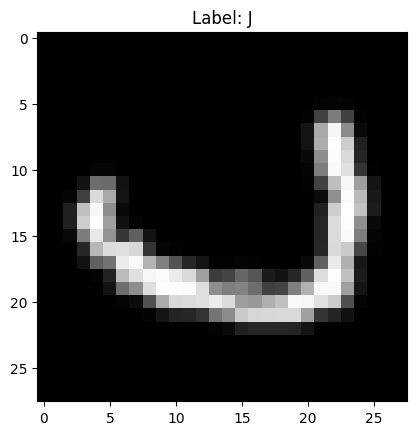

In [18]:
label = chr(y_test[2900] + ord('A'))

plt.imshow(X_test[2900].reshape(28,28), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

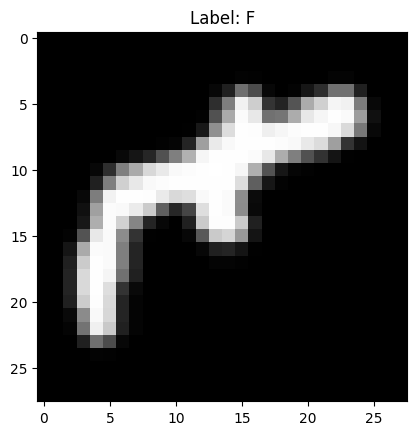

In [19]:
label = chr(y_test[10] + ord('A'))

plt.imshow(X_test[10].reshape(28,28), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

Forkert Prediction

555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


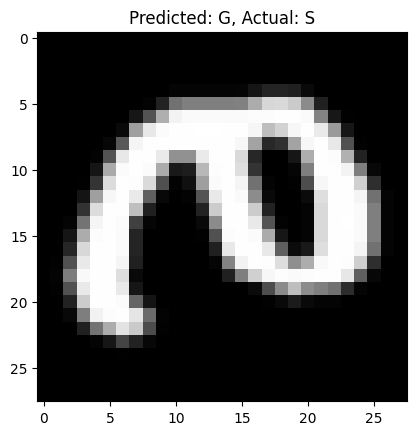

In [20]:
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
wrong = np.where(y_pred_cnn != y_test)[0]

plt.imshow(X_test_cnn[wrong[5]].reshape(28,28), cmap="gray")

predicted = chr(y_pred_cnn[wrong[5]] + ord('A'))
actual = chr(y_test[wrong[5]] + ord('A'))

plt.title(f"Predicted: {predicted}, Actual: {actual}")
plt.show()

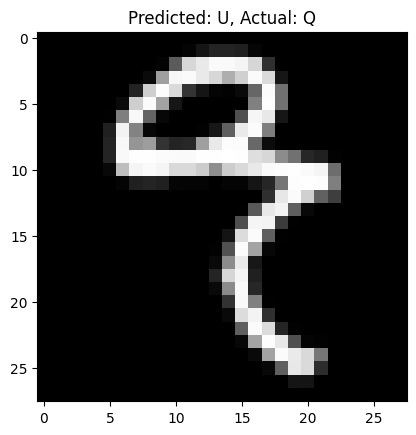

In [21]:
plt.imshow(X_test_cnn[wrong[2]].reshape(28,28), cmap="gray")

predicted = chr(y_pred_cnn[wrong[2]] + ord('A'))
actual = chr(y_test[wrong[2]] + ord('A'))

plt.title(f"Predicted: {predicted}, Actual: {actual}")
plt.show()

MLP Model History

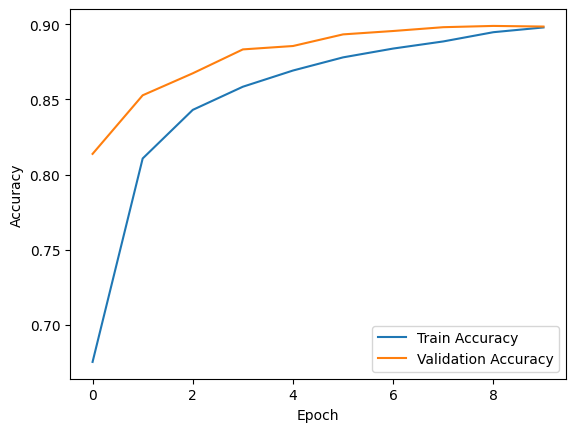

In [22]:
plt.plot(mlp_history.history['accuracy'], label='Train Accuracy')
plt.plot(mlp_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

CNN Model History

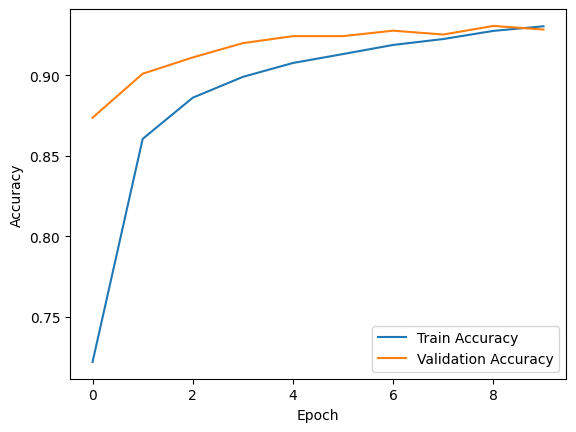

In [23]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

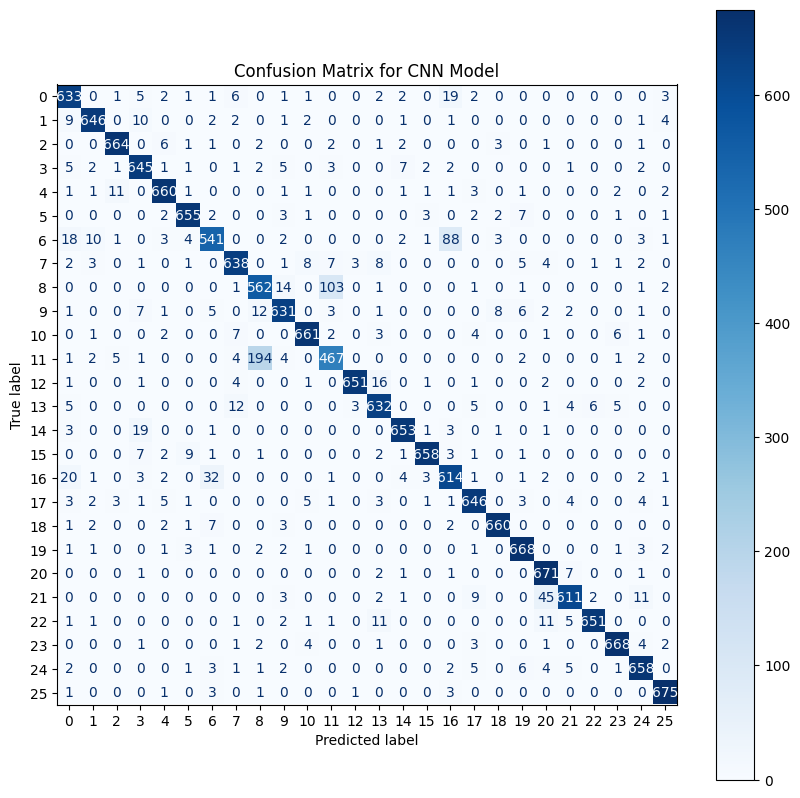

In [24]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=np.arange(26))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for CNN")
plt.show()

555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


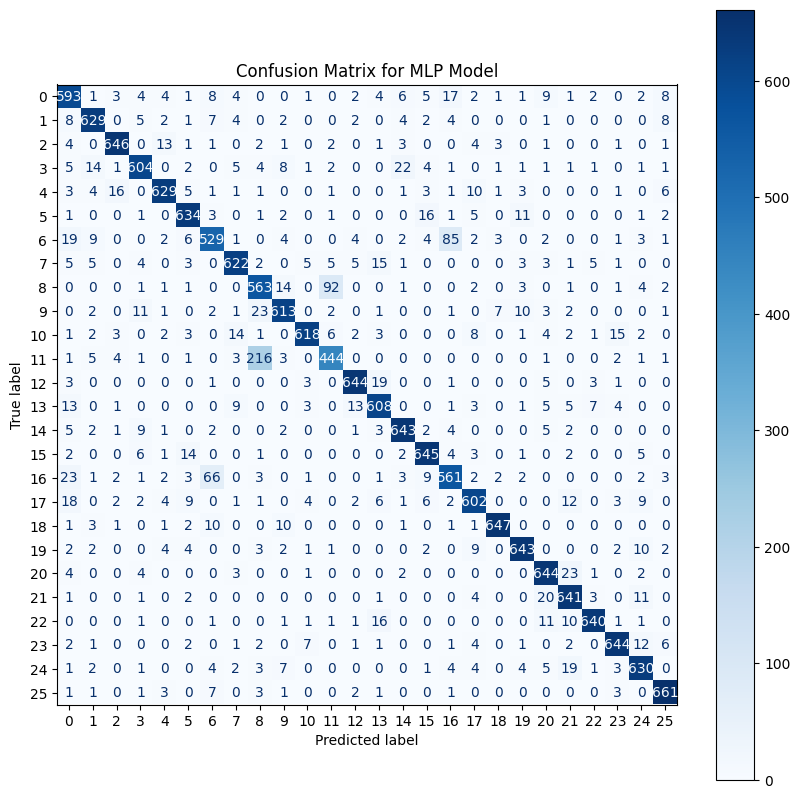

In [25]:
y_pred_mlp = np.argmax(mlp_model.predict(X_test), axis=1)

cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=np.arange(26))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for MLP")
plt.show()